# Clustering methods

L'objectif de ce TP est d'appliquer des méthodes de regroupement hiérarchique et de K-means sur des jeux de données synthéthiques. Ainsi, on analysera l'influence des hyperparamètres et les approches pour déterminer le nombre optimal de clusters.

L’objectif du clustering est de structurer les données en groupes homogènes appelées clusters. Bon clustering:
- minimise la dispersion intra-cluster
- maximise la séparation inter-cluster

Distances usuelles:
- Manhattan (Minkowski avec q=1)
- Euclidienne (Minkowski avec q=2)
- Hamming 

## Start with clustering 

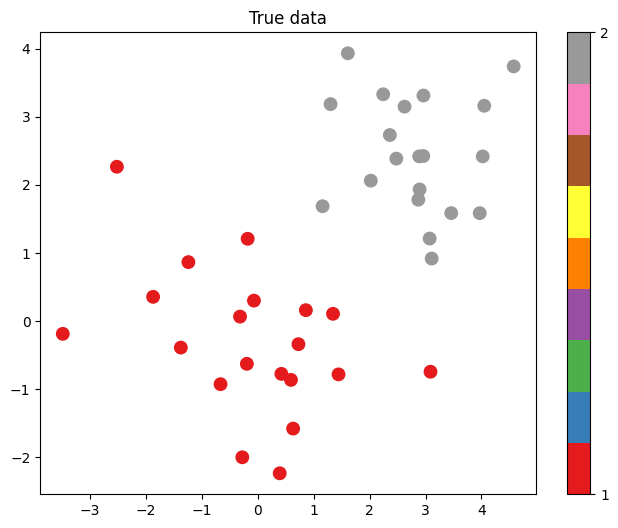

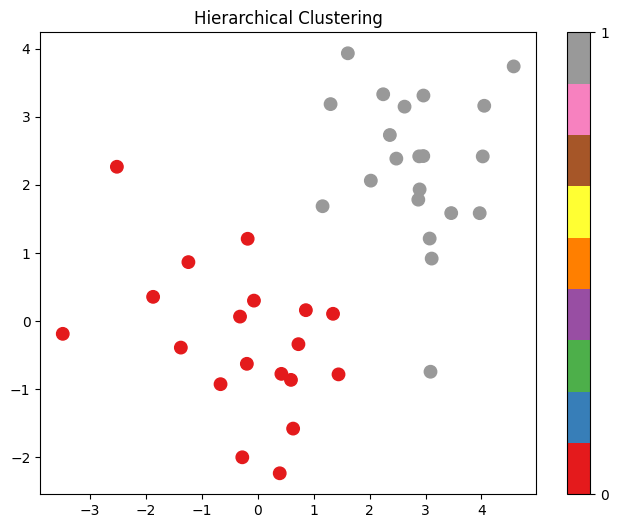

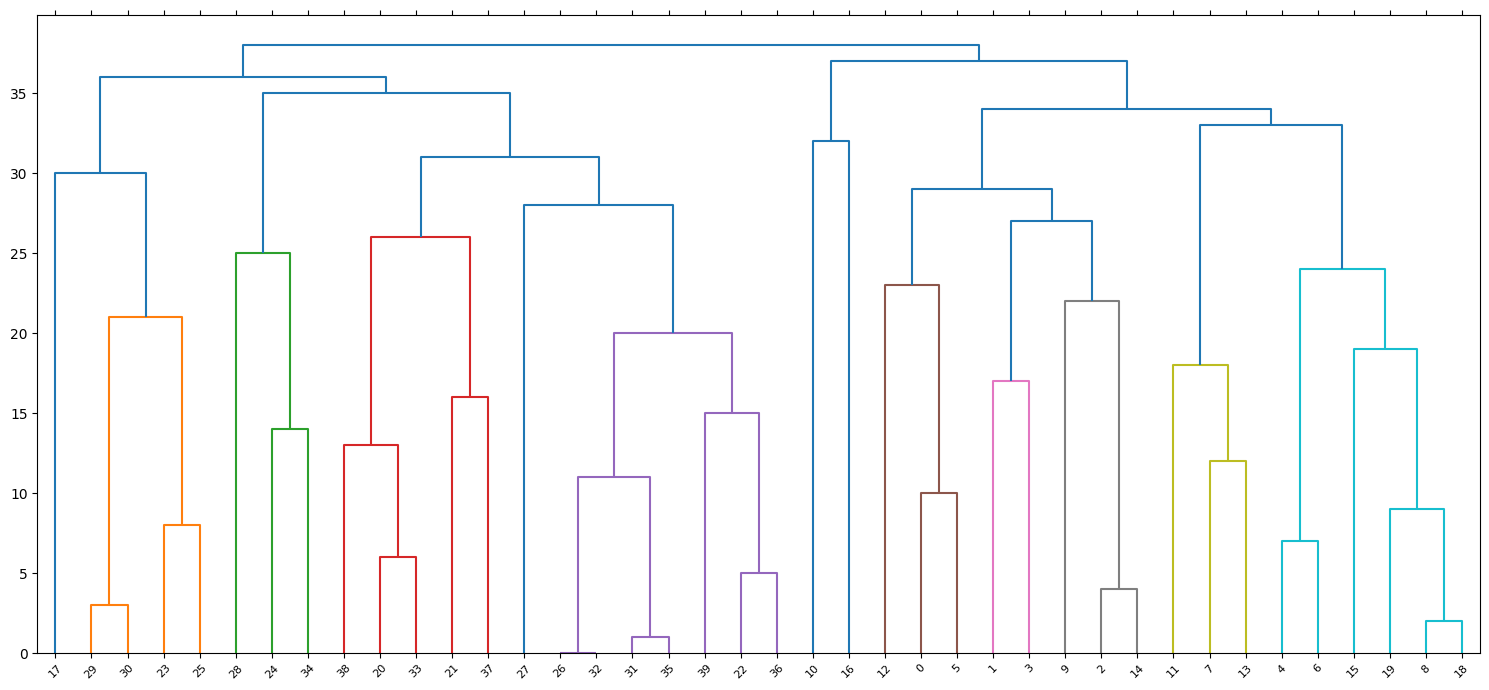

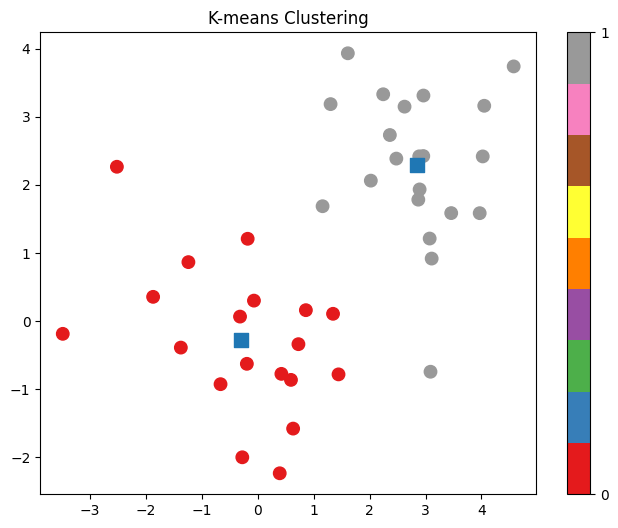

<Figure size 640x480 with 0 Axes>

In [15]:
%matplotlib inline
%run starter_clustering.py

### Clustering hiérarchique 

Le **clustering hiérarchique** organise les données sous forme d'une hiérarchie ou d'un arbre (le dendogramme).  
Le dendrogramme permet de représenter graphiquement les fusions successives.  
Le choix du critère (single linkage, average linkage …) peut changer radicalement le résultat.

Agglomératif (bottom-up):
1) Chaque xi est initialement son propre cluster.
2) A chaque étape, les deux clusters les plus proches sont fusionnées.
3) On répète jusqu'à obtenir le nombre de clusters souhaités ou jusqu'à ce qu'il ne reste qu'un cluster unique.

Divisif (top-down):
1) Tous les points sont rassemblés dans un seul cluster.
2) On divise progressivement les clusters jusqu'à obtenir le nombre de clusters souhaité.

Linkage methods (critères pour fusionner les clusters):
- ward: fusionne les clusters pour minimiser la variance à l'intérieur de chaque cluster 
=> clusters compacts, sphériques, très stable.  
- complete: fusion basée sur la distance maximale entre les points des clusters; évite l'enchaînement, peut séparer les agrégats allongés.  
- average: fusion basée sur la distance moyenne entre les points des clusters; compromis entre simple et complet.  
- single: fusion basée sur la distance minimale entre les points des clusters; peut produire un effet d'enchaînement (longs clusters reliant les points un à un).

### K-means

Le **K-means** est une méthode de partitionnement.
1) Choisir K centres initiaux.
2) Assigner chaque point au cluster le plus proche (selon la distance euclidienne).
3) Recalculer les centres des clusters comme moyenne des points assignés.
4) Répéter les étapes 2/3 jusqu'à convergence (cad que les clusters ne changent plus/très peu).

Limites:
- nécessite de fixer K à l’avance
- sensible aux outliers
- clusters supposés sphériques
- dépend de l’initialisation

### Comparaison K-means & clustering hiérarchique 

| Critère                | **K-Means**                     | **Hiérarchique**                           |
|------------------------|----------------------------------|---------------------------------------------|
| K fixé au départ   | Oui                              | Non                                         |
| Structure          | 1 seule partition                | Hiérarchie complète (dendrogramme)          |
| Distance           | Euclidienne (souvent)            | Choix du linkage (Ward, complete, etc.)    |
| Forme des clusters | Sphériques                       | Varie selon le linkage                      |
| Complexité         | Rapide                           | Plus lent                                   |
| Sensible aux outliers | Oui                           | Oui mais impact différent                   |


## Selecting the number of clusters 

In [16]:
# scipy.io pour les fichiers .mat
import scipy.io as sio

# sio.loadmat renvoie un dictionnaire
# on sélectionne la variable "george" => X: tableau contenant la matrice george
data = sio.loadmat("./george.mat")
print(data.keys())
X = data["george"]

dict_keys(['__header__', '__version__', '__globals__', 'george'])


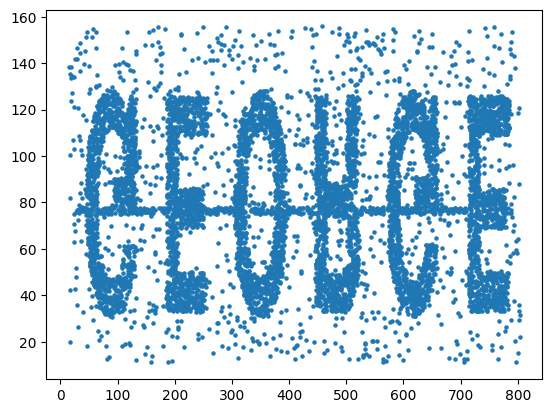

In [17]:
# affichage des données
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(X[:,0], X[:,1], s=5)
plt.show()

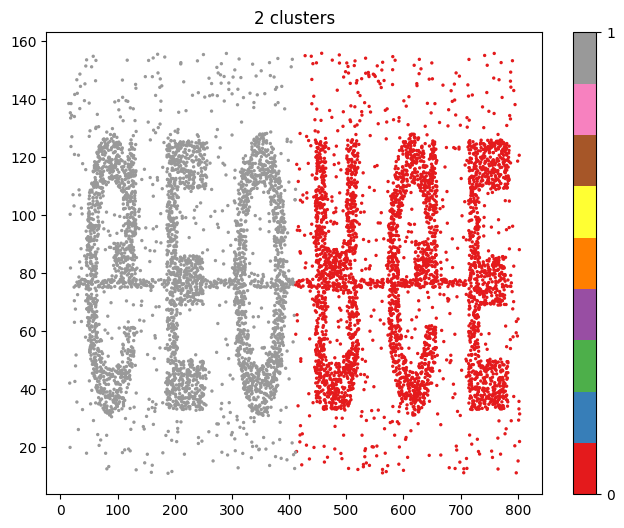

In [18]:
# nombre de clusters
K = 2

# K-means clustering method
# par défaut, les centres sont initialiés de manière aléatoire (init="random")
# on pourrait faire init="k-means++" pour une initialisation intelligence des centres
# initiaux pour être bien espacés
model = cluster.KMeans(n_clusters=K, init="k-means++")

# fit: le modèle apprend les clusters à partir des données 
# calcule les centres de clusters et assigne chaque point à son cluster le plus proche
# predict: retourne les indices de chaque cluster pour chaque point
# => retourne un tableau de taille n_samples; chaque élément indique le cluster du point xi
assigned_cluster = model.fit_predict(X)

plot_clusters(X, assigned_cluster, title=f"{K} clusters", symbolsize=2)

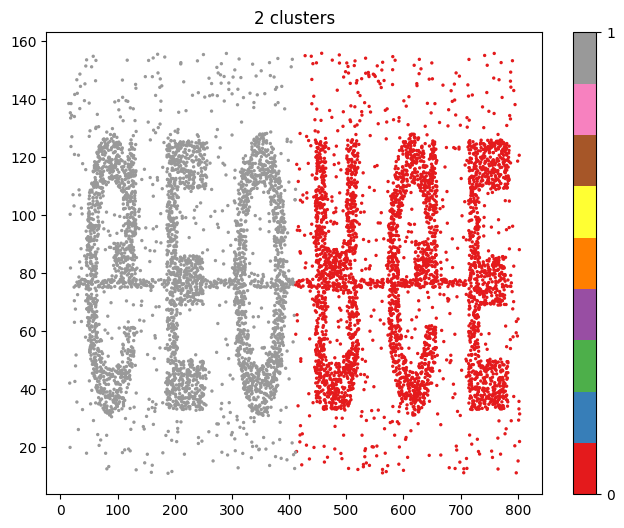

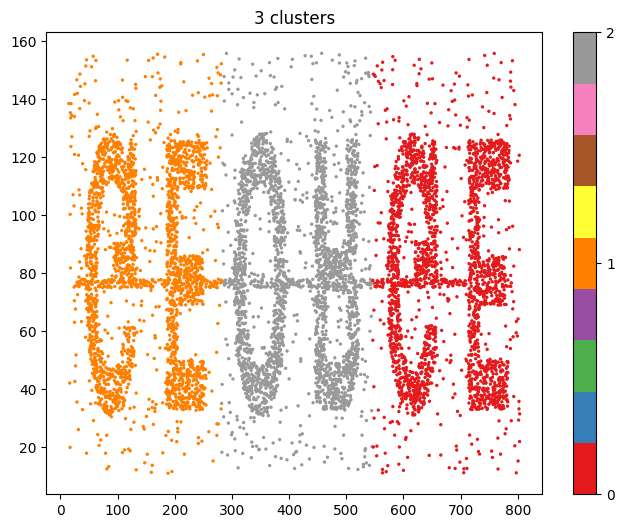

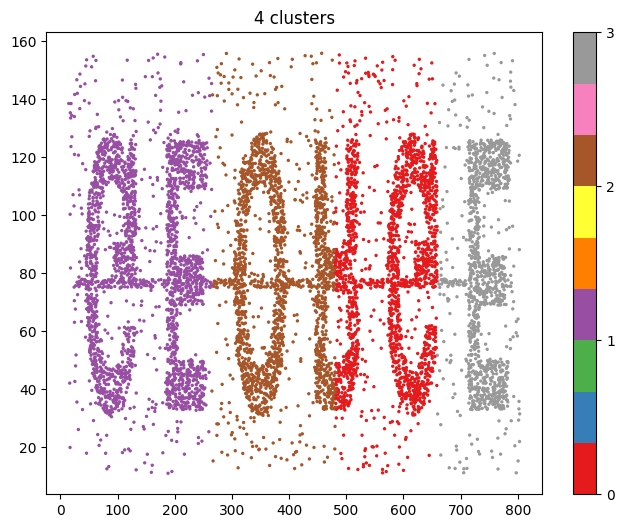

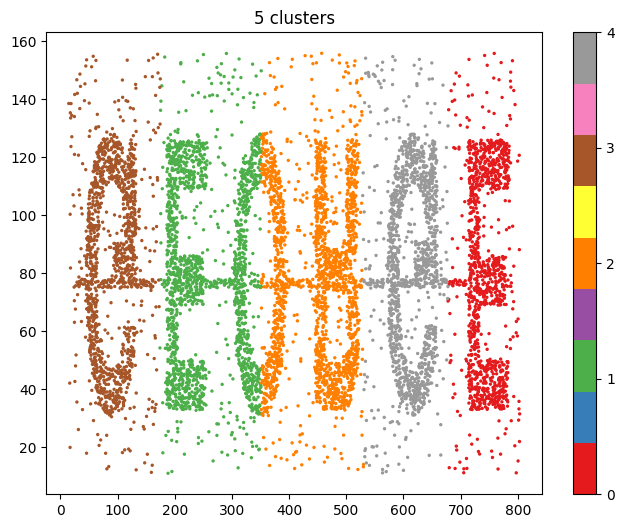

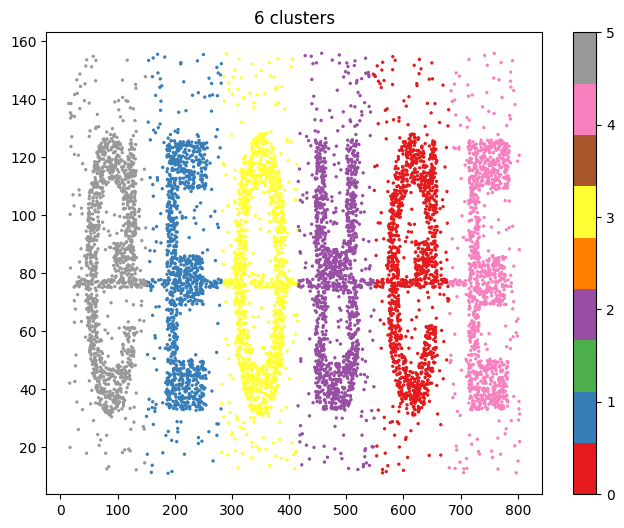

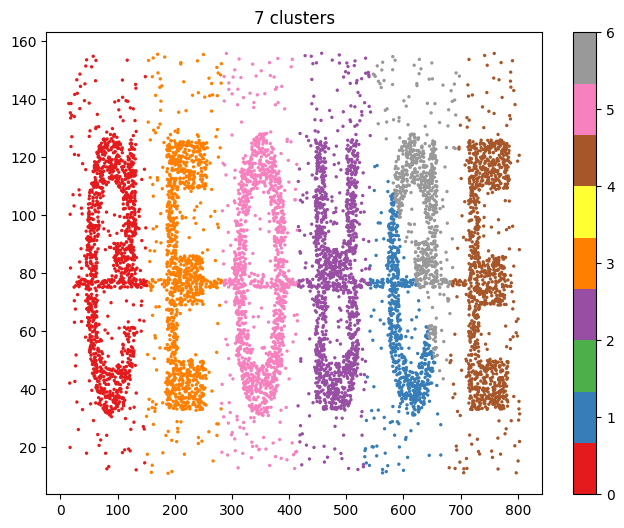

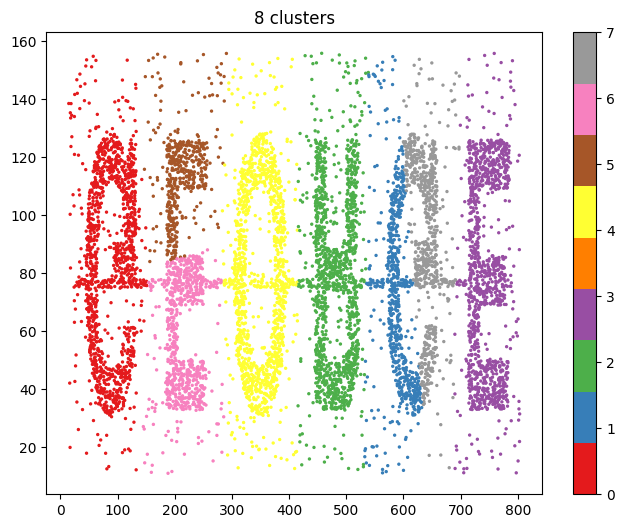

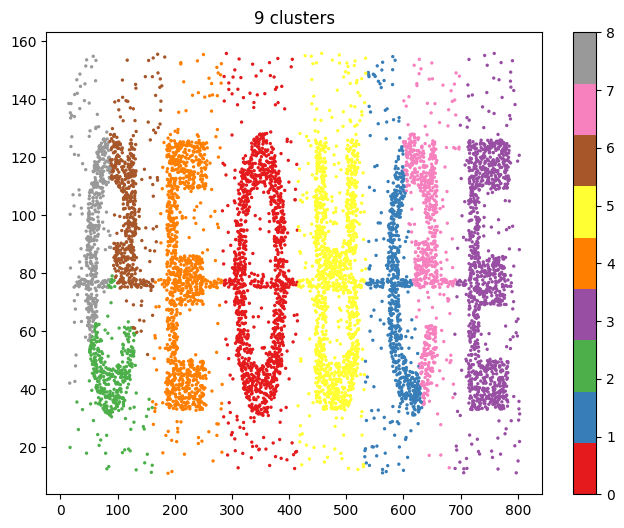

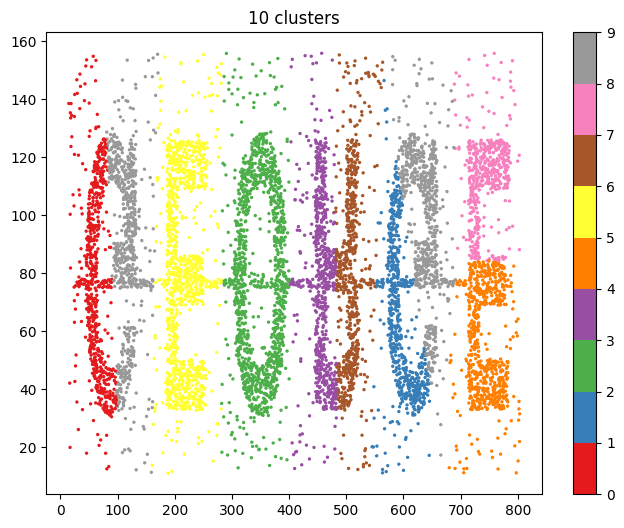

In [19]:
K = [2,3,4,5,6,7,8,9,10]
for i in K:
    model = cluster.KMeans(n_clusters=i, init="k-means++")
    assigned_cluster = model.fit_predict(X)
    plot_clusters(X, assigned_cluster, title=f"{i} clusters", symbolsize=2)

On obtient une séparation en K clusters. Lorsque K=6, un cluster représente une lettre.

L'objectif est de sélectionner le nombre optimal de clusters K. Pour ce faire, on utilise le score de silhouette, défini comme le coefficient de silhouette moyen de tous les échantillons.  
score de silhouette élevé => meilleur clustering.
- proche de 1 => clusters bien séparés et compacts.
- proche de 0 => clusters se chevauchent.

Pour n_clusters= 2, le silhouette score moyen est de 0.6120103557224367
Pour n_clusters= 3, le silhouette score moyen est de 0.5809858698046819
Pour n_clusters= 4, le silhouette score moyen est de 0.5070379128088404
Pour n_clusters= 5, le silhouette score moyen est de 0.505465428681648
Pour n_clusters= 6, le silhouette score moyen est de 0.5517105130024682
Pour n_clusters= 7, le silhouette score moyen est de 0.49916816359223515
Pour n_clusters= 8, le silhouette score moyen est de 0.46637548091781594
Pour n_clusters= 9, le silhouette score moyen est de 0.4533424908398867
Pour n_clusters= 10, le silhouette score moyen est de 0.42313889702847973
Pour n_clusters= 11, le silhouette score moyen est de 0.4308276061955407


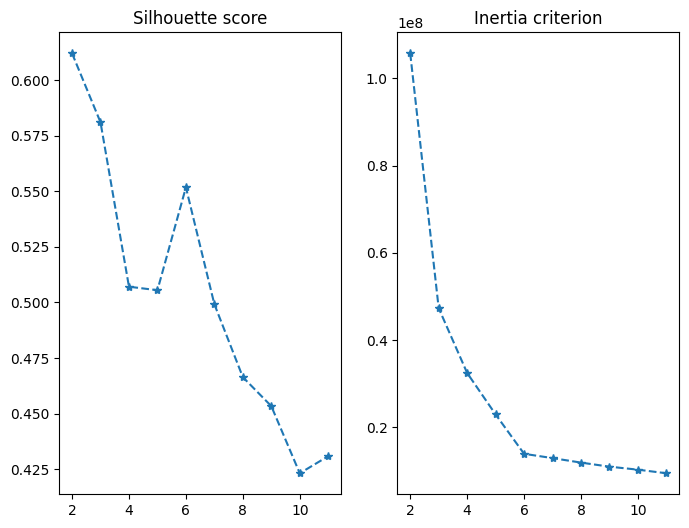

In [20]:
from sklearn.metrics import silhouette_score

vect_n_clusters = np.arange(2,12,1)
silhouette_index = np.empty(vect_n_clusters.shape)
inertia_index = np.empty(vect_n_clusters.shape)

for idx, n_clusters in enumerate(vect_n_clusters):
    model = cluster.KMeans(n_clusters = n_clusters)
    assigned_cluster = model.fit_predict(X)
    # calcule le silhouette score
    silhouette_index[idx] = silhouette_score(X, assigned_cluster)
    # somme des distances au carré entre chaque xi et le centre de son cluster
    # c'est la variance intra_cluster totale que K-means cherche à minimiser
    inertia_index[idx] = model.inertia_
    
    print(f"Pour n_clusters= {n_clusters}, le silhouette score moyen est de {silhouette_index[idx]}")
    
plt.figure(figsize=(8,6))
plt.subplot(121)
plt.plot(vect_n_clusters, silhouette_index, "*--")
plt.title("Silhouette score")
plt.subplot(122)
plt.plot(vect_n_clusters, inertia_index, "*--")
plt.title("Inertia criterion");

Inertie (méthode du "Elbow"): correspond à la somme des distances au carré entre chaque xi et le centre de son cluster. On cherche un "coude" dans la courbe du plot, celui-ci indiquant le point à partir duquel l'ajout de clusters supplémentaires n'apporte plus de gain significatif.  
Le choix optimal de K repose sur un compromis entre ces deux critères: il s'agit de sélectionner la valeur de K qui maximise le silhouette score tout en se situant danss la zone ou l'intertie se stabilise.  
Ici, K=6 semble être un très bon compromis, il est d'ailleurs cohérent à la structure réelle des données qu'on a pu observer: chaque cluser correspond à une lettre.

## Image segmentation

Les dimensions de l'image sont: 627 lignes, 837 colonnes and 3 canaux (RGB)


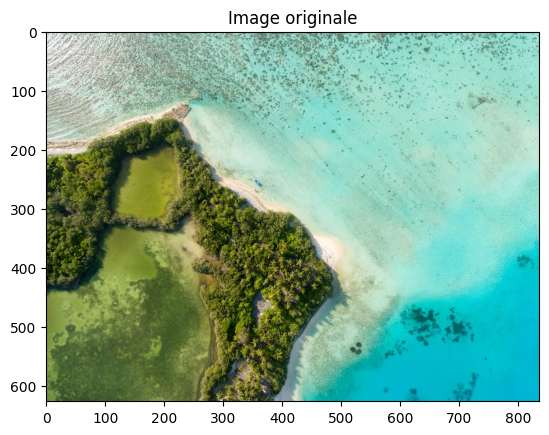

In [21]:
img = plt.imread("seaforest_small.jpeg")
n, m, d = img.shape
print(f"Les dimensions de l'image sont: {n} lignes, {m} colonnes and {d} canaux (RGB)")
plt.imshow(np.uint8(img))
plt.title("Image originale");

**vectoriser**: passer d'une structure multi-dimensionnelle à une liste de vecteurs.  
Permet d'appliquer des algorithmes comme K-means qui travaillent sur des vecteurs 2D.

Dans l'image originale, chaque pixel à 3 canaux pour les 3 couleurs RGB.  
On souhaite clusteriser l'image selon les couleurs donc on va vectoriser l'image en la transformant en matrice 2D (n*m, d):
- chaque ligne de x: un pixel
- chaque colonne de x: un canal couleur

In [22]:
# pixels "aplatis" pour former une liste de N observations. Chaque observation possède caractéristiques ( Rouge, Vert, Bleu)
X = np.reshape(img, (n*m, d))
K = 3
kmeans_image = cluster.KMeans(n_clusters=K)
kmeans_image.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


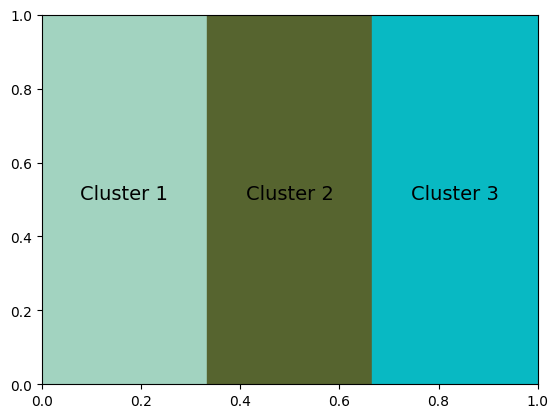

In [23]:
from utility import plot_rectangles_colors
centers = kmeans_image.cluster_centers_
plot_rectangles_colors(centers)

In [24]:
y = kmeans_image.predict(X)
print(y)
# y est un tableau d'indices: chaque pixel ici prend la coucleur du centre de son cluster
Xseg = centers[y]

[0 0 0 ... 2 2 2]


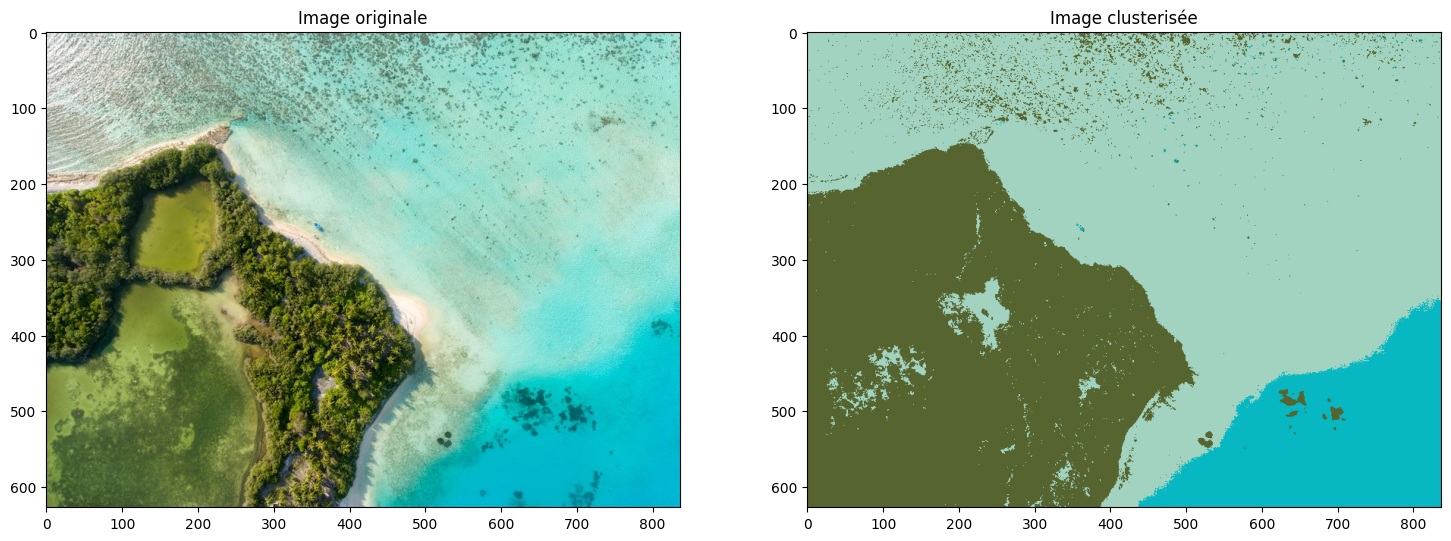

In [25]:
plt.figure(figsize=(18,10))
plt.subplot(121); plt.imshow(np.uint8(img));
plt.title("Image originale")
plt.subplot(122); plt.imshow(np.uint8(Xseg.reshape(n, m, d)));
plt.title("Image clusterisée");

- L'image originale est réduite à ses trois couleurs dominantes (vert foncé, vert clair, turquoise), identifiées comme les centroïdes des clusters.
- Zones homogènes : Le clustering a permis de structurer les pixels en catégories homogènes, facilitant l'analyse de zones comme la forêt ou l'eau.
- Compression avec perte : En remplaçant chaque pixel par le centre de son cluster, on perd les détails fins de texture au profit d'une structure simplifiée.

L'image est compressée en remplaçant la couleur de chaque pixel par l'index du centroïde le plus proche.

1. Données de l'image originale:
* Chaque pixel est codé sur 3 canaux (RGB).
* Chaque canal utilise 8 bits, soit 24 bits par pixel ($3 \times 8$).

2. Données de l'image segmentée ($K=3$):
* Indexation: Pour stocker 3 indices différents ($0, 1, 2$), nous avons besoin de 2 bits par pixel (car $2^1 < 3 \le 2^2$).
* Palette: On stocke les 3 couleurs réelles des centres $\mu_l$. Pour une image de grande taille, ce coût est négligeable.

3. Formule du taux de compression:
$$Taux = \frac{\text{Nombre de bits par pixel (Original)}}{\text{Nombre de bits par pixel (Compressé)}}$$

4. Résultat:
$$Taux = \frac{24}{2} = 12$$

Conclusion : Le passage à $K=3$ couleurs permet un taux de compression théorique de 12:1. L'image segmentée occupe environ 12 fois moins d'espace mémoire que l'image originale.

## Cluster and visualize digits 

In [31]:
digits = sio.loadmat("uspsasi.mat")
digits, labels = digits["x"], digits["y"][:,0]
X = digits

In [32]:
from sklearn.cluster import KMeans

In [33]:
K = 10
kmeans_digits = KMeans(n_clusters=K, random_state=42)
# label_clusters contient pour chaque xi le cluster auquel il appartient
labels_clusters = kmeans_digits.fit_predict(X)

On veut visualiser le cluster en 2D mais les données ont une dimension > 2D donc on doit appliquer une méthode de réduction de dimension:
- PCA: linéaire, rapide.
- t-SNE: non-linéaire, plus précise.

### Analyse en Composantes Principales (PCA)

La PCA est une méthode linéaire traitant les données comme un mélange d'information et de bruit. Elle identifie de nouvelles directions appelées composantes principales, où la première capture le maximum de variance et les suivantes la variance restante sous contrainte d'orthogonalité. Cette approche permet de conserver la structure essentielle tout en minimisant la perte d'information. La variance sert ici d'indicateur de dispersion.

Le processus suit des étapes rigoureuses :
1. Normalisation par centrage et réduction pour éviter que les variables à fortes unités ne biaisent le résultat.
2. Construction de la matrice de corrélation.
3. Calcul et tri décroissant des vecteurs et valeurs propres.
4. Sélection de q directions via un seuil de variance, la méthode du coude ou la validation croisée.
5. Projection des données dans ce nouvel espace réduit.

Malgré son efficacité, la PCA reste limitée aux relations linéaires et s'avère sensible aux valeurs aberrantes.

In [34]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)

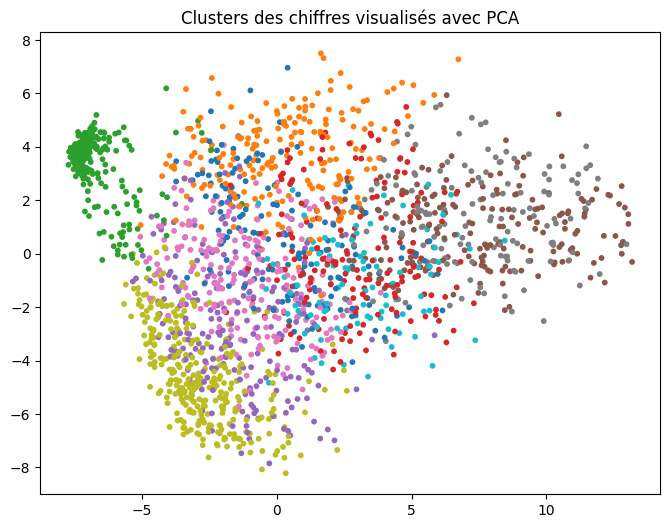

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_clusters, cmap='tab10', s=10)
plt.title("Clusters des chiffres visualisés avec PCA")
plt.show()

### Synthèse de la méthode t-SNE (t-distributed Stochastic Neighbor Embedding)

Le t-SNE est une technique non linéaire de réduction de dimension principalement utilisée pour la visualisation de données complexes. Contrairement à la PCA qui se base sur la variance globale, le t-SNE préserve les structures locales en conservant les distances relatives entre les points voisins.

Le processus repose sur les principes suivants :
1. Conversion des distances euclidiennes entre les points en probabilités de similitude dans l'espace d'origine.
2. Définition d'une distribution de probabilité similaire dans un espace de faible dimension (généralement 2D ou 3D).
3. Minimisation de la divergence entre ces deux distributions pour que les points proches restent proches après projection.



Les caractéristiques et limites majeures sont :
* Capacité à révéler des clusters et des structures que les méthodes linéaires ne perçoivent pas.
* Paramètre de perplexité crucial influençant le nombre de voisins pris en compte.
* Coût computationnel élevé en temps et en mémoire par rapport à la PCA.
* Nature stochastique impliquant que des exécutions différentes peuvent produire des visualisations légèrement distinctes.

In [36]:
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

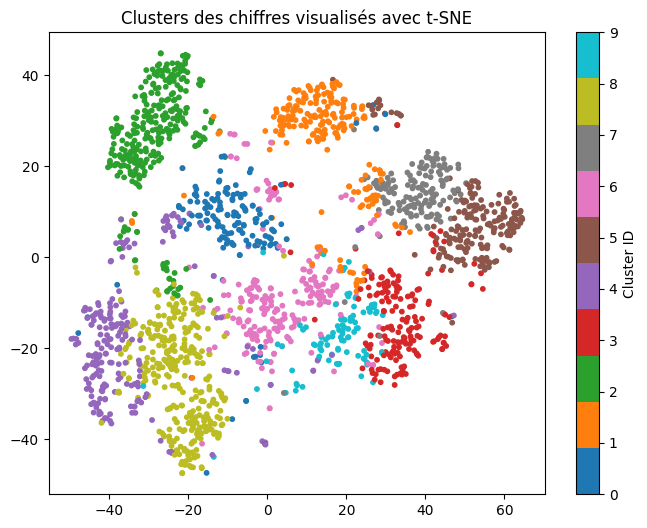

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_clusters, cmap='tab10', s=10)
plt.title("Clusters des chiffres visualisés avec t-SNE")
plt.colorbar(label='Cluster ID')
plt.show()